# ERSSTv5 Climate Indices

Plots three climate indices computed from regridded ERSSTv5:
1. **Niño3.4** — standard ENSO index
2. **ENSO CP/TP** — cold-tongue (N_CT) and warm-pool (N_WP) split
3. **IPO** — Interdecadal Pacific Oscillation (filtered + unfiltered)

Requires the regridded ERSSTv5 file from `inspect_regrid.ipynb`.

In [1]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt

import sys
from pathlib import Path

PROJECT_ROOT = Path("/home/lhoffma2/git/slowdown_arctic_seaice")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(sys.path[0])
from configs import paths
from src.data.observations.ersst.climate_indices import (
    compute_nino34_index,
    compute_enso_cp_tp_indices,
    compute_ipo_index,
    compute_arctic_sst_index,
    save_nino34,
    save_enso_cp_tp,
    save_ipo,
)

/home/lhoffma2/git/slowdown_arctic_seaice


In [2]:
# ── PATHS ── edit these to match your machine ──────────────────────────────
ERSST_REGRID = paths.ERSST_REGRIDDED
FORCED_EM = paths.CESM2LE_DIR / 'climate_indices'
PLOT_START   = 1990   # first year to show in timeseries plots
# ───────────────────────────────────────────────────────────────────────────

In [3]:
# Load regridded SST and coordinates
ds = nc.Dataset(ERSST_REGRID, 'r')
sst_obs  = np.array(ds.variables['sst_obs'])
lat      = np.array(ds.variables['lat_cesm2'])
lon      = np.array(ds.variables['lon_cesm2'])
ds.close()

# Build date / year arrays (ERSSTv5 starts Jan 1854)
ntime  = sst_obs.shape[0]
dates  = pd.date_range(start='1854-01-01', periods=ntime, freq='MS')
years  = dates.year.to_numpy()

print(f'SST shape : {sst_obs.shape}')
print(f'Date range: {dates[0].strftime("%Y-%m")} → {dates[-1].strftime("%Y-%m")}')

# Load CESM2-LE Arctic SST forced ensemble mean
ds = nc.Dataset(FORCED_EM / 'cesm2le_arctic_sst_forced_em.nc', 'r')
arctic_sst_forced_em = np.array(ds.variables['arctic_sst_forced_em_flat'])
ds.close()

print(f'Arctic SST forced EM shape: {arctic_sst_forced_em.shape}')

SST shape : (2060, 192, 288)
Date range: 1854-01 → 2025-08
Arctic SST forced EM shape: (1332,)


---
## 1. Niño3.4 (standard ENSO index)

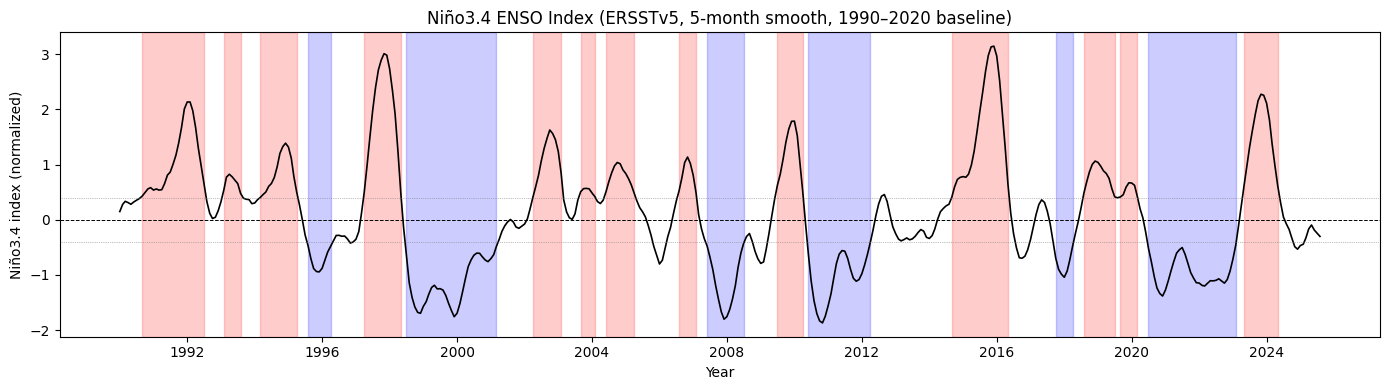

In [5]:
nino34, labels_34 = compute_nino34_index(sst_obs, lat, lon, years)

# Subset for plotting
y0 = np.where(years == PLOT_START)[0][0]
series = nino34[y0:]
phases = labels_34[y0:]
date   = dates[y0:]

fig, ax = plt.subplots(figsize=(14, 4))

# Phase shading
start = 0
for i in range(1, len(phases)):
    if phases[i] != phases[start]:
        if phases[start] != 0:
            color = 'red' if phases[start] == 1 else 'blue'
            ax.axvspan(date[start], date[i - 1], color=color, alpha=0.2)
        start = i
if phases[start] != 0:
    color = 'red' if phases[start] == 1 else 'blue'
    ax.axvspan(date[start], date[-1], color=color, alpha=0.2)

ax.plot(date, series, color='black', linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax.axhline( 0.4, color='gray', linewidth=0.5, linestyle=':')
ax.axhline(-0.4, color='gray', linewidth=0.5, linestyle=':')
ax.set_xlabel('Year')
ax.set_ylabel('Niño3.4 index (normalized)')
ax.set_title('Niño3.4 ENSO Index (ERSSTv5, 5-month smooth, 1990–2020 baseline)')
plt.tight_layout()
#plt.savefig('index_nino34.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# SST composites: Niño3.4 phases (El Niño / La Niña / Neutral)
import cartopy.crs as ccrs
import cmocean

month_all = np.arange(sst_obs.shape[0]) % 12

clim_all = np.array([
    np.nanmean(sst_obs[month_all == m], axis=0)
    for m in range(12)
])

sst_anom_all = sst_obs - clim_all[month_all]

# Remove global-mean SST at each time step to focus on spatial pattern
sst_anom_all = sst_anom_all - np.nanmean(sst_anom_all, axis=(1, 2), keepdims=True)

sst_nino   = np.nanmean(sst_anom_all[labels_34 ==  1], axis=0)
sst_nina   = np.nanmean(sst_anom_all[labels_34 == -1], axis=0)
sst_neutral = np.nanmean(sst_anom_all[labels_34 ==  0], axis=0)

plot_data = [
    {'data': sst_nino,    'title': 'SST anomaly: El Niño (Niño3.4+)'},
    {'data': sst_nina,    'title': 'SST anomaly: La Niña (Niño3.4−)'},
    {'data': sst_neutral, 'title': 'SST anomaly: Neutral (Niño3.4)'},
]

fig, axes = plt.subplots(
    3, 1, figsize=(12, 18),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)}
)
for ax, d in zip(axes, plot_data):
    ax.set_global()
    ax.coastlines(linewidth=0.8)
    im = ax.pcolormesh(
        lon, lat, d['data'],
        cmap=cmocean.cm.balance,
        shading='auto',
        transform=ccrs.PlateCarree()
    )
    im.set_clim(-1, 1)
    ax.set_xticks(range(-180, 181, 60))
    ax.set_yticks(range(-90, 91, 30))
    ax.set_title(d['title'], fontsize=12)

cbar = fig.colorbar(im, ax=axes, orientation='horizontal',
                    fraction=0.04, pad=0.06, shrink=0.6)
cbar.set_label('SST anomaly (°C)', fontsize=11)
plt.tight_layout()
plt.show()

---
## 2. ENSO CP/TP — cold-tongue (N_CT) and warm-pool (N_WP)

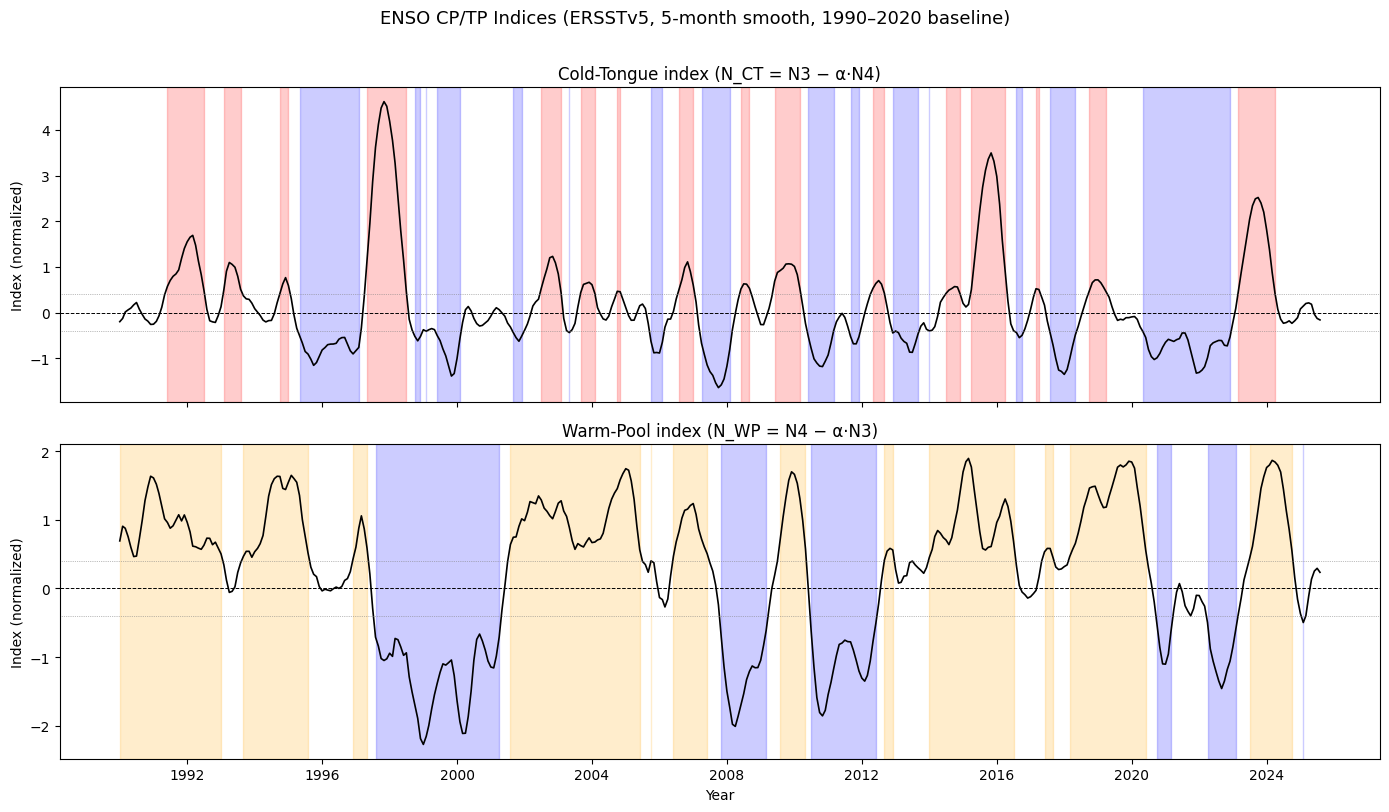

In [7]:
result = compute_enso_cp_tp_indices(sst_obs, lat, lon, years)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, key, label_key, title, color_pos in [
    (axes[0], 'n_ct', 'labels_n_ct',
     'Cold-Tongue index (N_CT = N3 − α·N4)', 'red'),
    (axes[1], 'n_wp', 'labels_n_wp',
     'Warm-Pool index (N_WP = N4 − α·N3)', 'orange'),
]:
    series = result[key][y0:]
    phases = result[label_key][y0:]

    start = 0
    for i in range(1, len(phases)):
        if phases[i] != phases[start]:
            if phases[start] != 0:
                c = color_pos if phases[start] == 1 else 'blue'
                ax.axvspan(date[start], date[i - 1], color=c, alpha=0.2)
            start = i
    if phases[start] != 0:
        c = color_pos if phases[start] == 1 else 'blue'
        ax.axvspan(date[start], date[-1], color=c, alpha=0.2)

    ax.plot(date, series, color='black', linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.axhline( 0.4, color='gray', linewidth=0.5, linestyle=':')
    ax.axhline(-0.4, color='gray', linewidth=0.5, linestyle=':')
    ax.set_ylabel('Index (normalized)')
    ax.set_title(title)

axes[-1].set_xlabel('Year')
plt.suptitle('ENSO CP/TP Indices (ERSSTv5, 5-month smooth, 1990–2020 baseline)',
             fontsize=13, y=1.01)
plt.tight_layout()
#plt.savefig('index_enso_cp_tp.png', dpi=150, bbox_inches='tight')
plt.show()

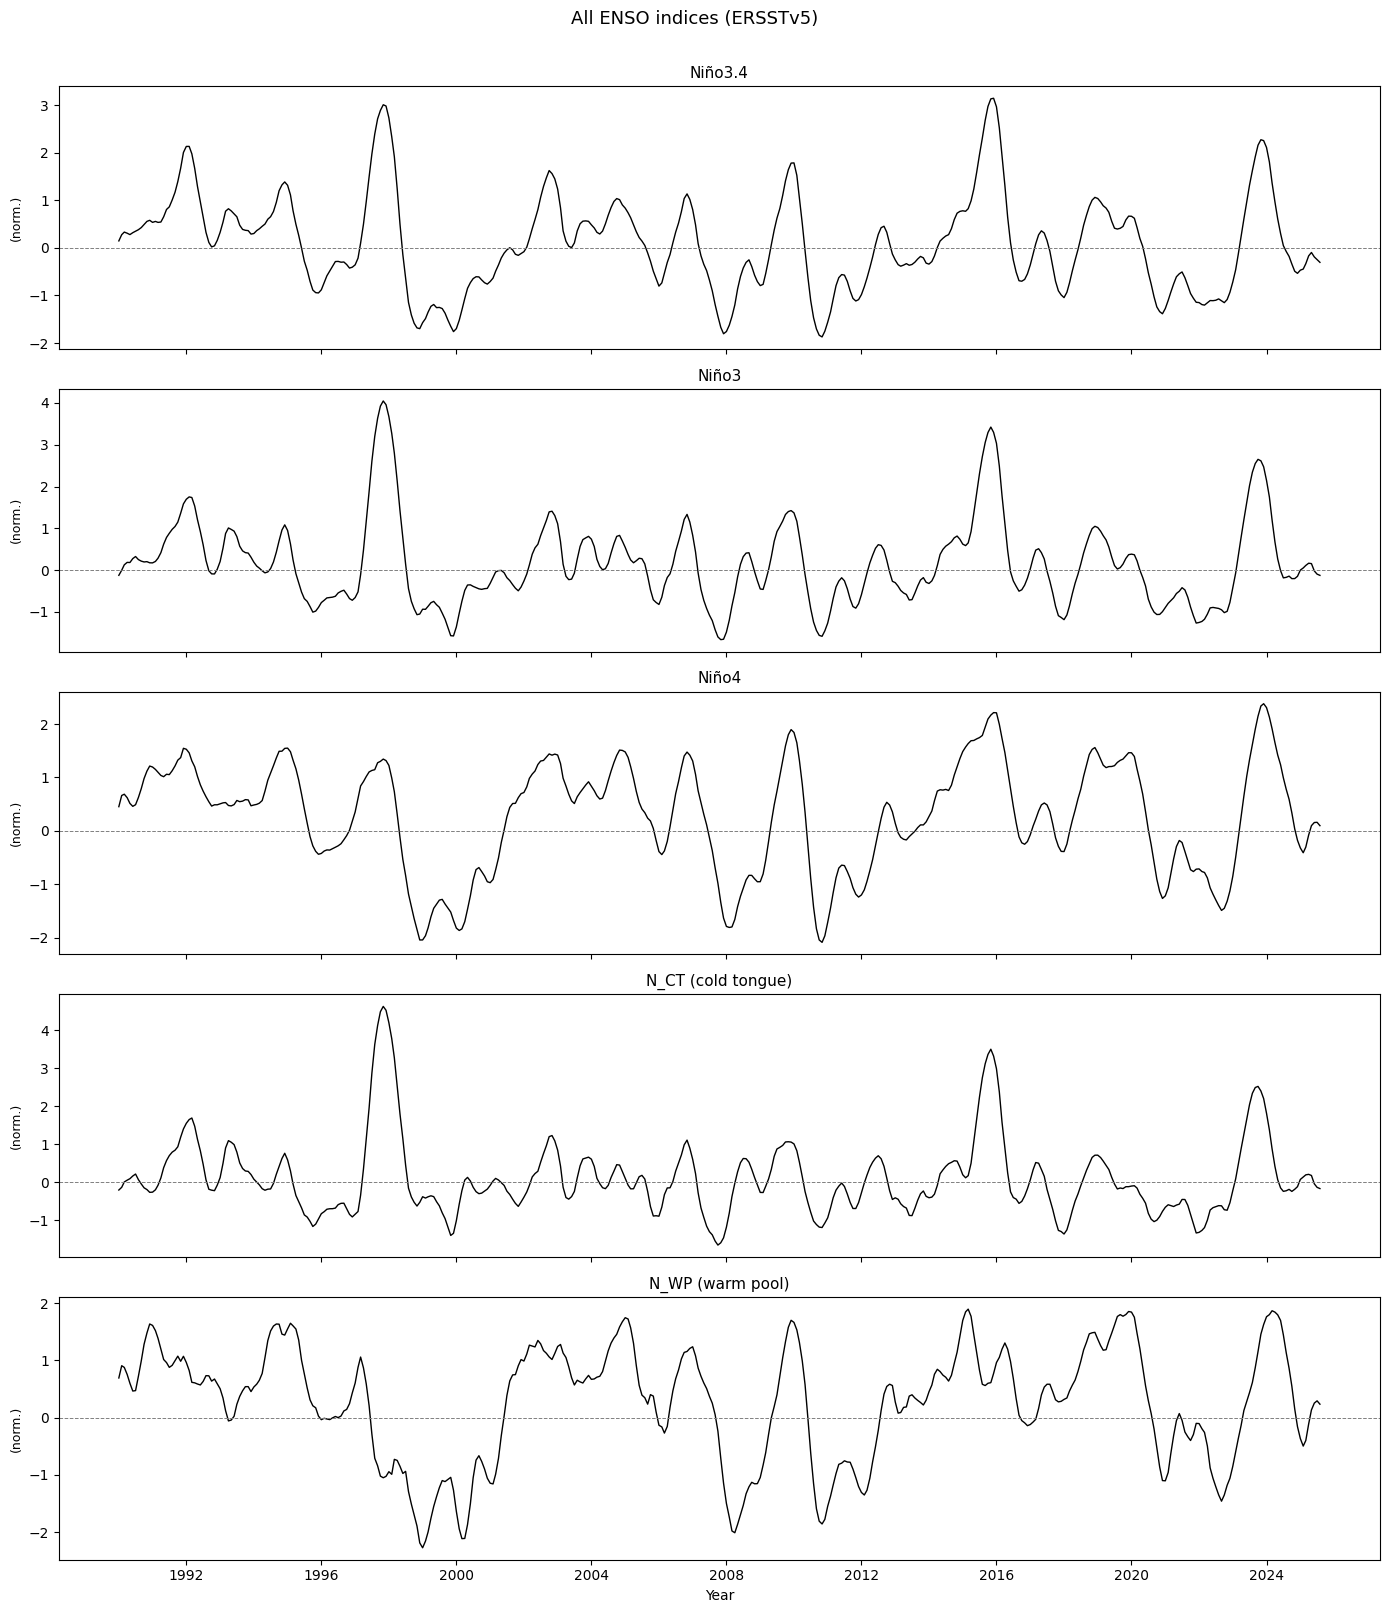

In [8]:
# Optional: all five indices side by side
keys   = ['n34',     'n3',      'n4',      'n_ct',          'n_wp']
titles = ['Niño3.4', 'Niño3',   'Niño4',   'N_CT (cold tongue)', 'N_WP (warm pool)']

fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)
for ax, key, title in zip(axes, keys, titles):
    ax.plot(date, result[key][y0:], color='black', linewidth=1)
    ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
    ax.set_ylabel('(norm.)', fontsize=9)
    ax.set_title(title, fontsize=11)

axes[-1].set_xlabel('Year')
plt.suptitle('All ENSO indices (ERSSTv5)', fontsize=13, y=1.005)
plt.tight_layout()
#plt.savefig('index_enso_all.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. IPO — Interdecadal Pacific Oscillation

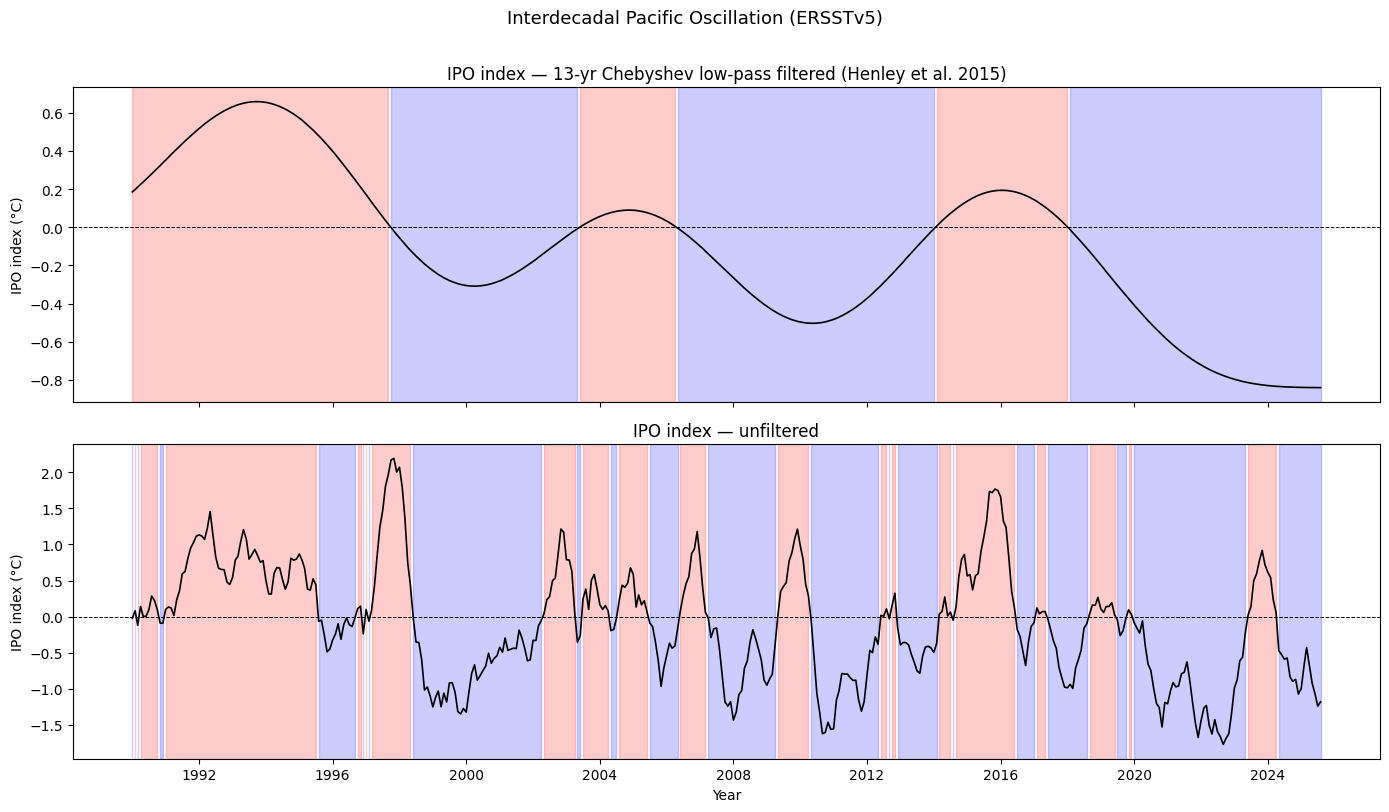

In [6]:
ipo, ipo_filtered, labels, labels_filtered = compute_ipo_index(sst_obs, lat, lon, years)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, series, phases, title in [
    (axes[0], ipo_filtered[y0:], labels_filtered[y0:],
     'IPO index — 13-yr Chebyshev low-pass filtered (Henley et al. 2015)'),
    (axes[1], ipo[y0:],          labels[y0:],
     'IPO index — unfiltered'),
]:
    start = 0
    for i in range(1, len(phases)):
        if phases[i] != phases[start]:
            if phases[start] != 0:
                c = 'red' if phases[start] == 1 else 'blue'
                ax.axvspan(date[start], date[i - 1], color=c, alpha=0.2)
            start = i
    if phases[start] != 0:
        c = 'red' if phases[start] == 1 else 'blue'
        ax.axvspan(date[start], date[-1], color=c, alpha=0.2)

    ax.plot(date, series, color='black', linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_ylabel('IPO index (°C)')
    ax.set_title(title)

axes[-1].set_xlabel('Year')
plt.suptitle('Interdecadal Pacific Oscillation (ERSSTv5)', fontsize=13, y=1.01)
plt.tight_layout()
#plt.savefig('index_ipo.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# SST composites: IPO+ vs IPO- (filtered phases)
import cartopy.crs as ccrs
import cmocean

month = np.arange(sst_obs.shape[0]) % 12

clim = np.array([
    np.nanmean(sst_obs[month == m], axis=0)
    for m in range(12)
])

sst_anom = sst_obs - clim[month]

sst_pos = np.nanmean(sst_anom[labels_filtered ==  1], axis=0)
sst_neg = np.nanmean(sst_anom[labels_filtered == -1], axis=0)

plot_data = [
    {'data': sst_pos, 'title': 'SST anomaly: IPO+ (filtered)'},
    {'data': sst_neg, 'title': 'SST anomaly: IPO− (filtered)'},
]

fig, axes = plt.subplots(
    2, 1, figsize=(12, 12),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)}
)
for ax, d in zip(axes, plot_data):
    ax.set_global()
    ax.coastlines(linewidth=0.8)
    im = ax.pcolormesh(
        lon, lat, d['data'],
        cmap=cmocean.cm.balance,
        shading='auto',
        transform=ccrs.PlateCarree()
    )
    im.set_clim(-1, 1)
    ax.set_xticks(range(-180, 181, 60))
    ax.set_yticks(range(-90, 91, 30))
    ax.set_title(d['title'], fontsize=12)

cbar = fig.colorbar(im, ax=axes, orientation='horizontal',
                    fraction=0.04, pad=0.06, shrink=0.6)
cbar.set_label('SST anomaly (°C)', fontsize=11)
plt.tight_layout()
plt.show()

---
## 4. Arctic SST Index

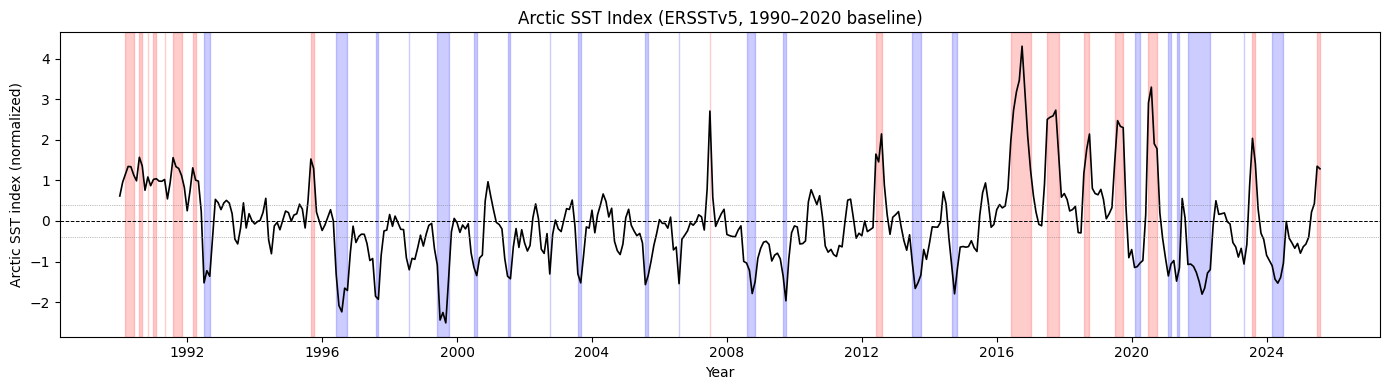

In [8]:
arctic_sst_index, labels, diagnostics = compute_arctic_sst_index(
    sst_obs, arctic_sst_forced_em, lat, lon, years, smooth_months=None
)

# Build aligned dates using the obs slice returned by the function
obs_i0, obs_i1 = diagnostics['obs_slice']
dates_aligned = dates[obs_i0:obs_i1]
years_aligned = diagnostics['years_aligned']

# Subset for plotting
y1 = np.where(years_aligned == PLOT_START)[0][0]
series = arctic_sst_index[y1:]
phases = labels[y1:]
date   = dates_aligned[y1:]

fig, ax = plt.subplots(figsize=(14, 4))

# Phase shading
if len(phases) > 0:
    start = 0
    for i in range(1, len(phases)):
        if phases[i] != phases[start]:
            if phases[start] != 0:
                color = 'red' if phases[start] == 1 else 'blue'
                ax.axvspan(date[start], date[i - 1], color=color, alpha=0.2)
            start = i

    if phases[start] != 0:
        color = 'red' if phases[start] == 1 else 'blue'
        ax.axvspan(date[start], date[-1], color=color, alpha=0.2)

ax.plot(date, series, color='black', linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax.axhline( 0.4, color='gray', linewidth=0.5, linestyle=':')
ax.axhline(-0.4, color='gray', linewidth=0.5, linestyle=':')
ax.set_xlabel('Year')
ax.set_ylabel('Arctic SST index (normalized)')
ax.set_title('Arctic SST Index (ERSSTv5, 1990–2020 baseline)')
plt.tight_layout()
plt.show()

In [ ]:
# SST composites: Arctic SST+ vs Arctic SST−
import cartopy.crs as ccrs
import cmocean

# align with labels time index (starts in 1990)
sst_obs_1990 = sst_obs[(1990 - 1854)*12:, :, :]

# assume sst_obs_1990 shape = [time, lat, lon], monthly
month = np.arange(sst_obs_1990.shape[0]) % 12

# anomaly from climatological mean seasonal cycle
clim = np.array([
    np.nanmean(sst_obs_1990[month == m], axis=0)
    for m in range(12)
])

sst_anom = sst_obs_1990 - clim[month]

# anomaly from global mean SST (remove global mean at each time step to focus on spatial pattern)
sst_anom = sst_anom - np.nanmean(sst_anom, axis=(1,2), keepdims=True)

sst_pos  = np.nanmean(sst_anom[labels ==  1], axis=0)
sst_neg  = np.nanmean(sst_anom[labels == -1], axis=0)

plot_data = [
    {'data': sst_pos, 'title': 'SST anomaly: Arctic SST+'},
    {'data': sst_neg, 'title': 'SST anomaly: Arctic SST−'},
]

fig, axes = plt.subplots(
    2, 1, figsize=(12, 12),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)}
)
for ax, d in zip(axes, plot_data):
    ax.set_global()
    ax.coastlines(linewidth=0.8)
    im = ax.pcolormesh(
        lon, lat, d['data'],
        cmap=cmocean.cm.balance,
        shading='auto',
        transform=ccrs.PlateCarree()
    )
    im.set_clim(-1, 1)
    ax.set_xticks(range(-180, 181, 60))
    ax.set_yticks(range(-90, 91, 30))
    ax.set_title(d['title'], fontsize=12)

cbar = fig.colorbar(im, ax=axes, orientation='horizontal',
                    fraction=0.04, pad=0.06, shrink=0.6)
cbar.set_label('SST anomaly (°C)', fontsize=11)
plt.tight_layout()
plt.show()